In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [4]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
df = pd.read_csv('Train.csv')

print("Dataset Shape:", df.shape)

Dataset Shape: (10999, 12)


In [7]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [8]:
X = df.drop(["Reached.on.Time_Y.N"], axis=1)
y = df["Reached.on.Time_Y.N"]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="logloss",   # important (removes warning)
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [11]:
y_pred = xgb_model.predict(X_test)

print("\nFirst Predictions:", y_pred[:10])


First Predictions: [1 1 0 0 0 0 0 1 0 1]


In [12]:
print("\n=== Model Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


=== Model Performance ===
Accuracy: 0.6554545454545454

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.75      0.64       887
           1       0.78      0.59      0.67      1313

    accuracy                           0.66      2200
   macro avg       0.67      0.67      0.65      2200
weighted avg       0.69      0.66      0.66      2200



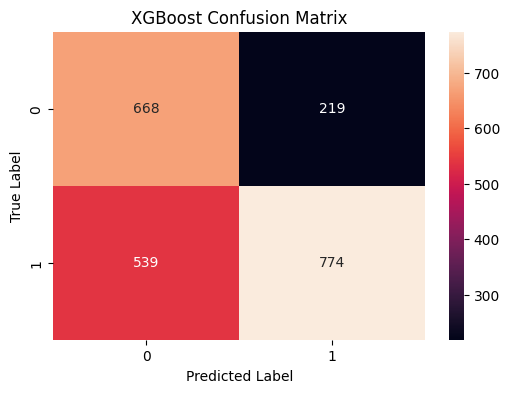

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()


Top Features:
                   Feature  Importance
0                      ID    0.380189
8       Warehouse_block_C    0.049287
11  Mode_of_Shipment_Road    0.048365
9       Warehouse_block_D    0.047775
1     Customer_care_calls    0.045152
3     Cost_of_the_Product    0.043448
5        Discount_offered    0.043038
6           Weight_in_gms    0.041739
10      Warehouse_block_F    0.041471
2         Customer_rating    0.039576


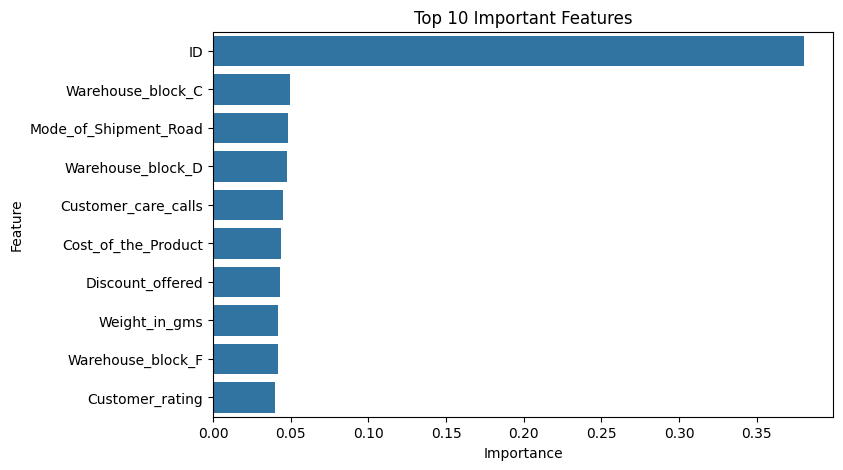

In [14]:
importances = xgb_model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Features:\n", feat_df.head(10))

# Plot feature importance
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

In [15]:
os.makedirs("models", exist_ok=True)

with open("models/xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print("\nModel saved successfully!")


Model saved successfully!


In [16]:
with open("models/xgb_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Test loaded model
test_pred = loaded_model.predict(X_test[:5])
print("\nLoaded Model Predictions:", test_pred)


Loaded Model Predictions: [1 1 0 0 0]
